# Exploratory Data Analysis

### Import Libraries

In [48]:
import pandas as pd
import numpy as np

from matplotlib import pyplot as plt; plt.rcParams['figure.dpi'] = 120
import seaborn as sns; sns.set_theme(style='whitegrid', palette='muted')
import os; os.chdir('/Users/aadityaparanjape/Downloads/IDX Exchange')

import warnings; warnings.filterwarnings('ignore')

### Load Data and Restrict Analysis

In [5]:
raw_data = pd.read_csv('data/initial/Combined_Housing_Data.csv')
raw_data.head()

,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,...,LotSizeDimensions,LotSizeArea,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict
0,ContraCosta,ContraCosta,"Carpet,Tile,Wood",NaN,NaN,NaN,False,1998000.0,1150041639,teresa@teresahooper.com,...,NaN,10080.0,NaN,False,3.0,San Ramon Valley,94596,975.0,10080.0,NaN
1,Mlslistings,Mlslistings,NaN,False,NaN,NaN,NaN,NaN,1150038872,homes@roomsantacruz.com,...,NaN,5663.0,NaN,NaN,5.0,Other,95018,NaN,5663.0,NaN
2,SanDiego,SanDiego,"Carpet,Wood",True,NaN,NaN,False,2214421.0,1150038683,laura@lauralothianrealestate.com,...,NaN,34745.0,NaN,False,3.0,NaN,91364,NaN,34745.0,NaN
3,Mlslistings,Mlslistings,NaN,False,NaN,NaN,NaN,1200000.0,1150038607,trung.lam@kw.com,...,NaN,6600.0,NaN,False,2.0,Other,95121,NaN,6600.0,NaN
4,TriCounties,TriCounties,NaN,True,NaN,NaN,True,3300.0,1150038314,c21themvpteam@gmail.com,...,NaN,17500.0,4.0,False,2.0,Jurupa Unified,92509,0.0,17500.0,NaN


In [6]:
print(f'Total rows loaded: {len(raw_data)} rows')
print(f'Total columns: {len(raw_data.columns)} columns')

Total rows loaded: 248808 rows
Total columns: 78 columns


In [10]:
# restrict analysis
data = raw_data[(raw_data['PropertyType'] == 'Residential') & (raw_data['PropertySubType'] == 'SingleFamilyResidence')]
print(f'Number of rows removed: {len(raw_data) - len(data)} rows ({(len(data) / len(raw_data)) * 100:.2f}% of total data)')

Number of rows removed: 125354 rows (49.62% of total data)


In [11]:
data.head()

,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,...,LotSizeDimensions,LotSizeArea,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict
0,ContraCosta,ContraCosta,"Carpet,Tile,Wood",NaN,NaN,NaN,False,1998000.0,1150041639,teresa@teresahooper.com,...,NaN,10080.0,NaN,False,3.0,San Ramon Valley,94596,975.0,10080.0,NaN
2,SanDiego,SanDiego,"Carpet,Wood",True,NaN,NaN,False,2214421.0,1150038683,laura@lauralothianrealestate.com,...,NaN,34745.0,NaN,False,3.0,NaN,91364,NaN,34745.0,NaN
3,Mlslistings,Mlslistings,NaN,False,NaN,NaN,NaN,1200000.0,1150038607,trung.lam@kw.com,...,NaN,6600.0,NaN,False,2.0,Other,95121,NaN,6600.0,NaN
7,Mlslistings,Mlslistings,NaN,False,NaN,NaN,NaN,3100000.0,1150032869,vickie@realsmartgroup.com,...,NaN,8262.0,NaN,False,1.0,San Jose Unified,95124,NaN,8262.0,NaN
9,Mlslistings,Mlslistings,NaN,False,NaN,NaN,NaN,2900000.0,1150028403,vickie@realsmartgroup.com,...,NaN,9222.0,NaN,False,2.0,Other,95128,NaN,9222.0,NaN


In [12]:
data.info(verbose=False)

<class 'pandas.core.frame.DataFrame'>
Index: 123454 entries, 0 to 248804
Columns: 78 entries, BuyerAgentAOR to MiddleOrJuniorSchoolDistrict
dtypes: float64(27), int64(3), object(48)
memory usage: 74.4+ MB


### Quality of Data

Let's take a look at the distribution of missing values across the columns in the dataset. This helps us understands whether to drop, impute, or flag the missing values in any one column

In [20]:
missing = data.isnull().sum()
missing_pct = (missing / len(data) * 100).round(1)
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).sort_values('Missing %', ascending=False)

# Show columns that have at least some missing data
missing_nonzero = missing_df[missing_df['Missing Count'] > 0]
print(f"Columns with missing values: {len(missing_nonzero)} out of {len(data.columns)} columns")
missing_nonzero.head(30)

Columns with missing values: 61 out of 78 columns


,Missing Count,Missing %
MiddleOrJuniorSchoolDistrict,123454,100.0
FireplacesTotal,123454,100.0
AboveGradeFinishedArea,123454,100.0
TaxAnnualAmount,123454,100.0
TaxYear,123454,100.0
ElementarySchoolDistrict,123454,100.0
CoveredSpaces,123454,100.0
BusinessType,123454,100.0
WaterfrontYN,123382,99.9
BelowGradeFinishedArea,122564,99.3


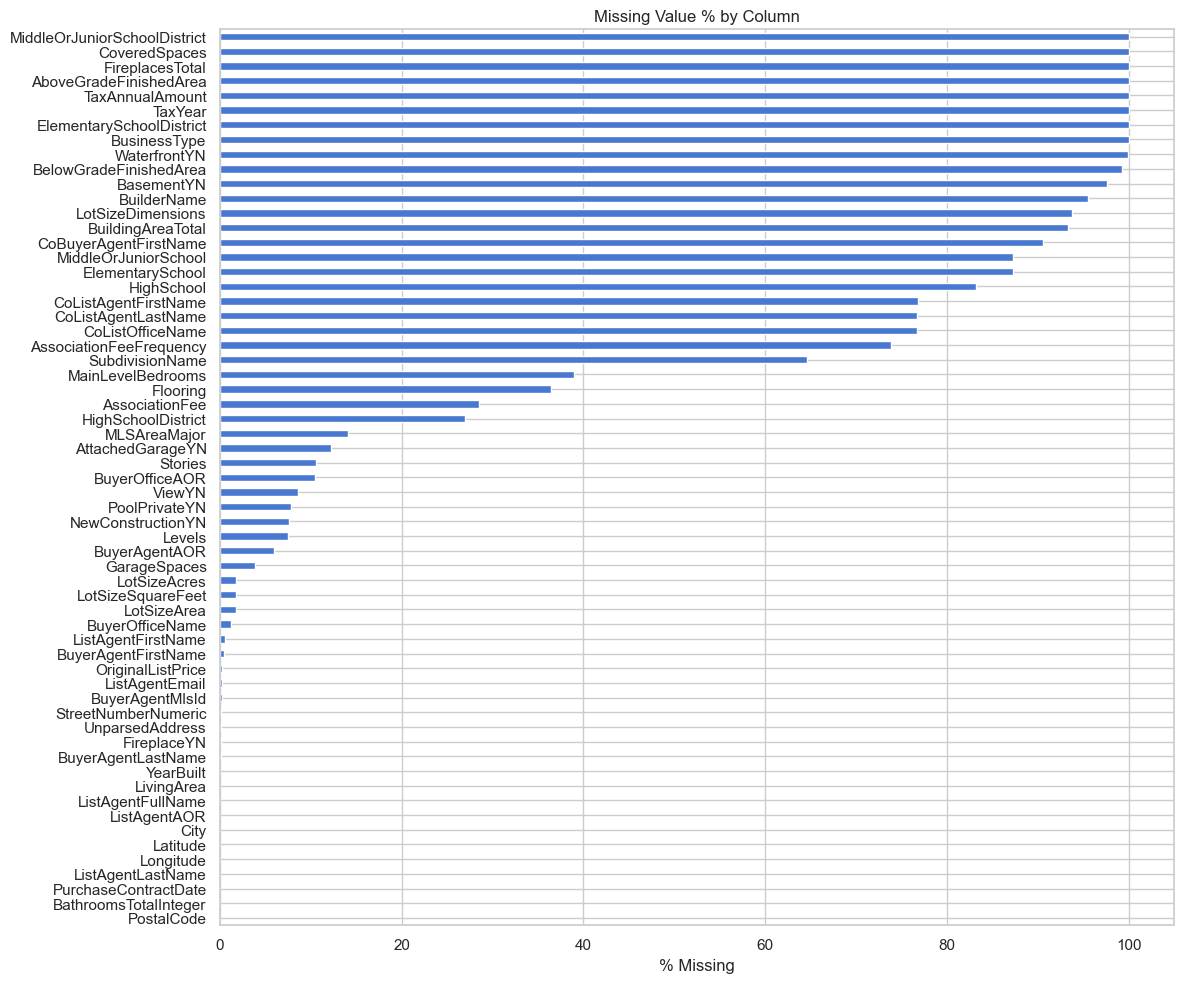

In [28]:
# distribution of missing values across all the columns
missing_pct = data.isnull().mean() * 100
missing_pct[missing_pct > 0].sort_values(ascending=True).plot(kind='barh', figsize=(12, 10))
plt.xlabel('% Missing')
plt.title('Missing Value % by Column')
plt.tight_layout(); plt.show()

**Data Quality Summary:** From the above chart, we can see that multiple columns, such as `CoveredSpaces` and `FireplacesTotal`, are entirely filled with missing values. In the case of these empty columns, we can safely drop them completely, as they will not contribute to predictions at all. For the columns with moderate missingness, such as `MainLevelBedrooms` and `Flooring`, we must impute missing values or create indicator variables.

### Outliers

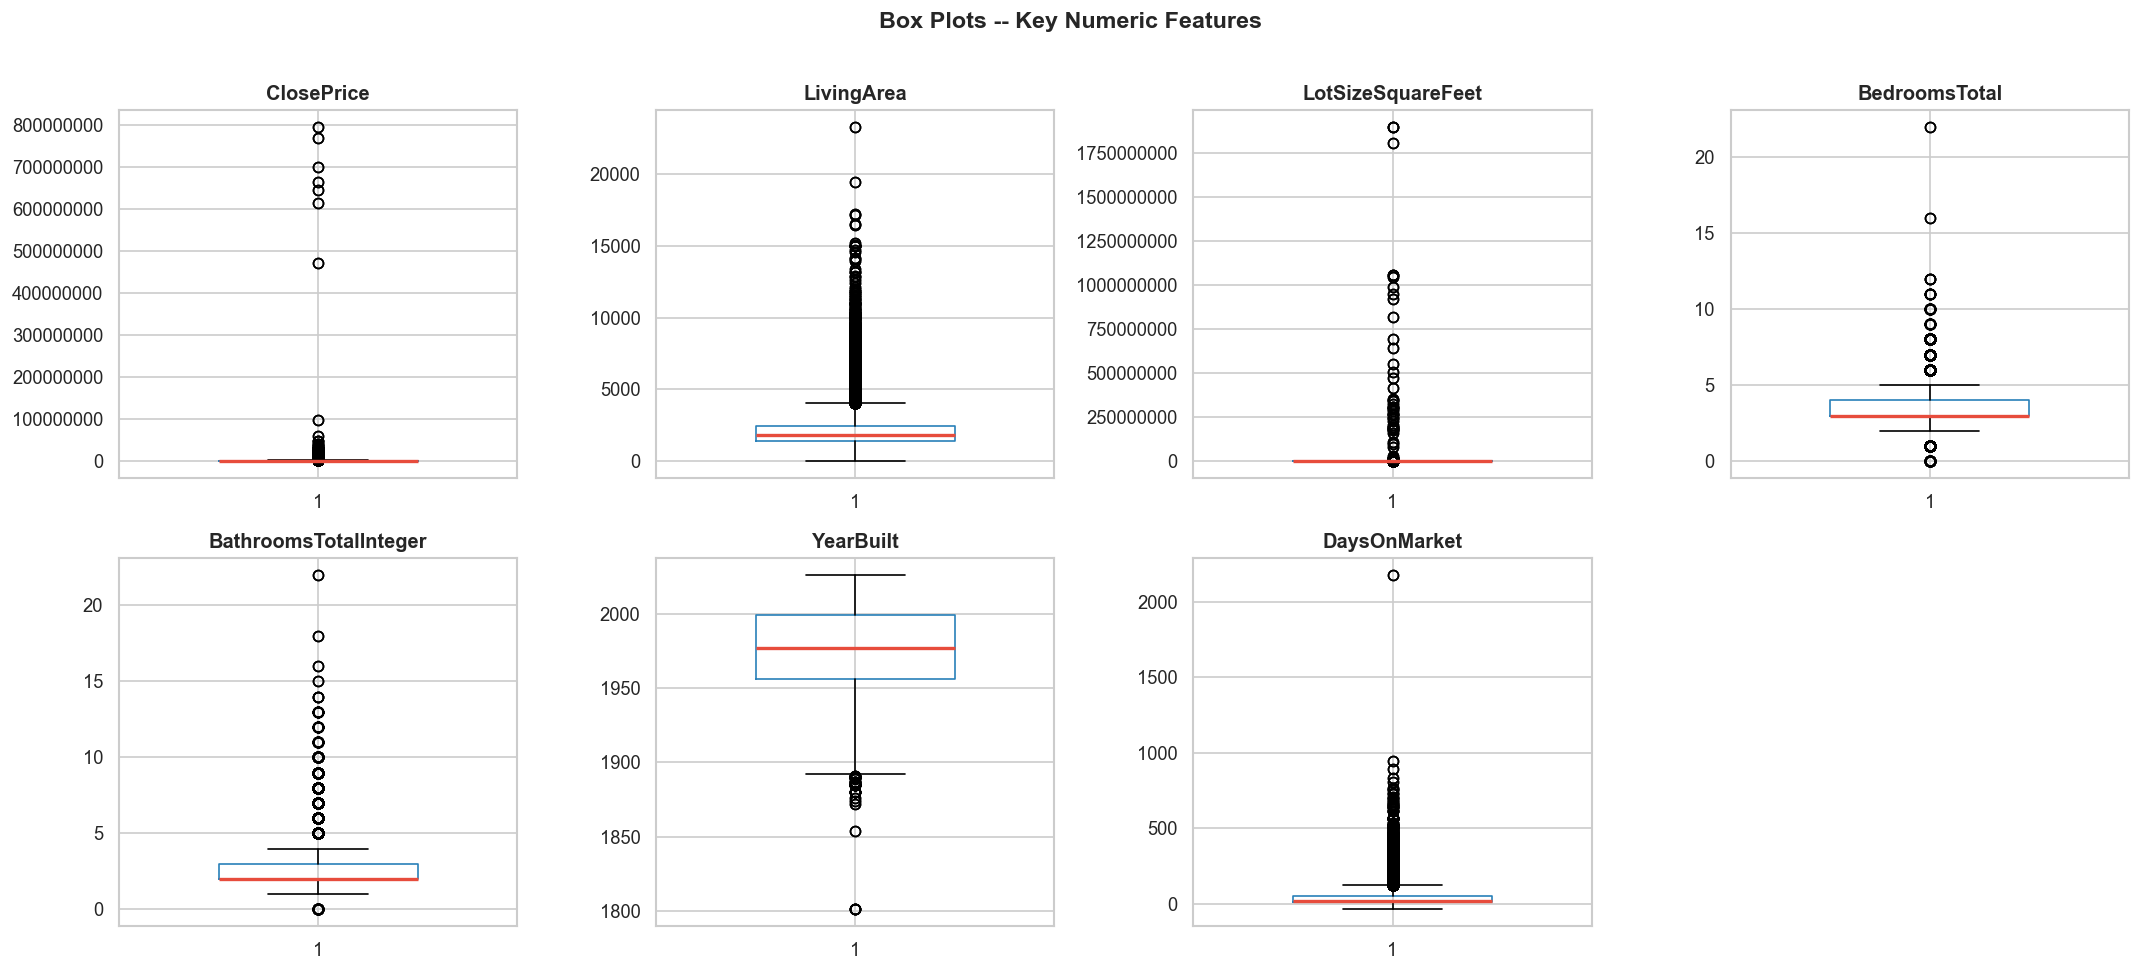

In [36]:
key_cols  = ['ClosePrice', 'LivingArea', 'LotSizeSquareFeet', 'BedroomsTotal',
               'BathroomsTotalInteger', 'YearBuilt', 'DaysOnMarket']

fig, axes = plt.subplots(2,4, figsize = (18,8))
axes = axes.flatten()

for i, col in enumerate(key_cols):
    specific_col = data[col].dropna()
    axes[i].boxplot(specific_col, vert=True, widths=0.5,
                    boxprops=dict(color='#2980b9'),
                    medianprops=dict(color='#e74c3c', linewidth=2))
    axes[i].set_title(col, fontweight='bold')
    axes[i].ticklabel_format(style='plain', axis='y')

axes[-1].axis('off')
fig.suptitle('Box Plots -- Key Numeric Features', fontweight='bold', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [31]:
# Quantify the extremes
print("=== Extreme Value Summary ===\n")
for col in ['ClosePrice', 'LivingArea', 'LotSizeSquareFeet', 'BathroomsTotalInteger']:
    specific_col = data[col].dropna()
    q1, q3 = specific_col.quantile(0.25), specific_col.quantile(0.75)
    iqr = q3 - q1
    upper = q3 + 3 * iqr  # using 3x IQR for "extreme" outliers
    n_extreme = (specific_col > upper).sum()
    print(f"{col}:")
    print(f"  IQR: {iqr:,.0f} | 3×IQR upper bound: {upper:,.0f}")
    print(f"  Extreme outliers (>{upper:,.0f}): {n_extreme:,} ({n_extreme/len(specific_col)*100:.2f}%)")
    print(f"  Max: {specific_col.max():,.0f}\n")

=== Extreme Value Summary ===

ClosePrice:
  IQR: 805,000 | 3×IQR upper bound: 3,840,000
  Extreme outliers (>3,840,000): 4,146 (3.36%)
  Max: 796,000,000

LivingArea:
  IQR: 1,069 | 3×IQR upper bound: 5,662
  Extreme outliers (>5,662): 1,278 (1.04%)
  Max: 23,314

LotSizeSquareFeet:
  IQR: 4,791 | 3×IQR upper bound: 24,827
  Extreme outliers (>24,827): 11,284 (9.30%)
  Max: 1,897,473,600

BathroomsTotalInteger:
  IQR: 1 | 3×IQR upper bound: 6
  Extreme outliers (>6): 1,204 (0.98%)
  Max: 22



**Outlier Summary:** `ClosePrice` has extreme outliers (max $796 million), as well as in `LivingArea` (max 23,314 sq. ft.) and `LotSizeSquareFeet` (max 1,897,473,600 sq. ft.; almost certainly a data error). Capping should be considered before modeling.


### Target Variable Distribution
As `ClosePrice` is our target variable, it is important to investigate it's distribution. From the outlier observarions, `ClosePrice` appears to be right-skewed, which is why we will apply a log-transform to normalize the distribution.

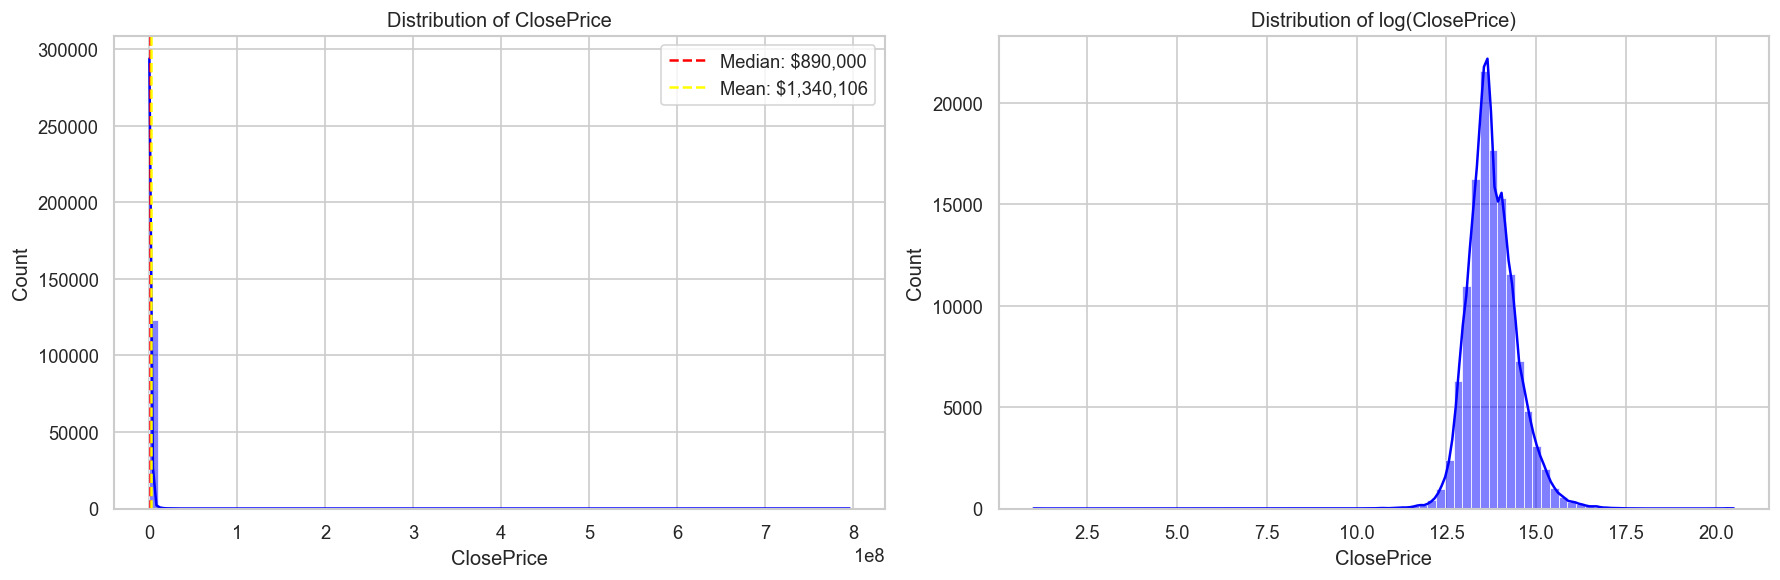

In [40]:
# dsitrbution of normal ClosePrice and logClosePrice
fig, axes = plt.subplots(1,2, figsize = (15,5))

# normal ClosePrice distribution
sns.histplot(data['ClosePrice'].dropna(), bins=80, kde = True, color = 'blue', edgecolor = 'white', ax = axes[0])
axes[0].axvline(data['ClosePrice'].median(), color = 'red', ls = '--', label = f'Median: ${data['ClosePrice'].median():,.0f}')
axes[0].axvline(data['ClosePrice'].mean(), color = 'yellow', ls = '--', label = f'Mean: ${data['ClosePrice'].mean():,.0f}')
axes[0].legend()
axes[0].set_title('Distribution of ClosePrice')

# logClosePrice distribution
logClosePrice = np.log1p(data['ClosePrice'].dropna())
sns.histplot(logClosePrice, bins=80, kde = True, color = 'blue', edgecolor = 'white', ax = axes[1])
axes[1].set_title('Distribution of log(ClosePrice)')

plt.tight_layout(); plt.show()

**Target Variable Distribution Summary:** `ClosePrice` is incredibly right-skewed. `logClosePrice` dramatically reduces the skewness and significantly normalizes the distribution, making it more appropriate than normal `ClosePrice` for linear models.

### Bivariate Analysis
Using scatter plots, we can bette understand the relationships between variables; more specifically, we can examine the relationships between various variables and `ClosePrice`.

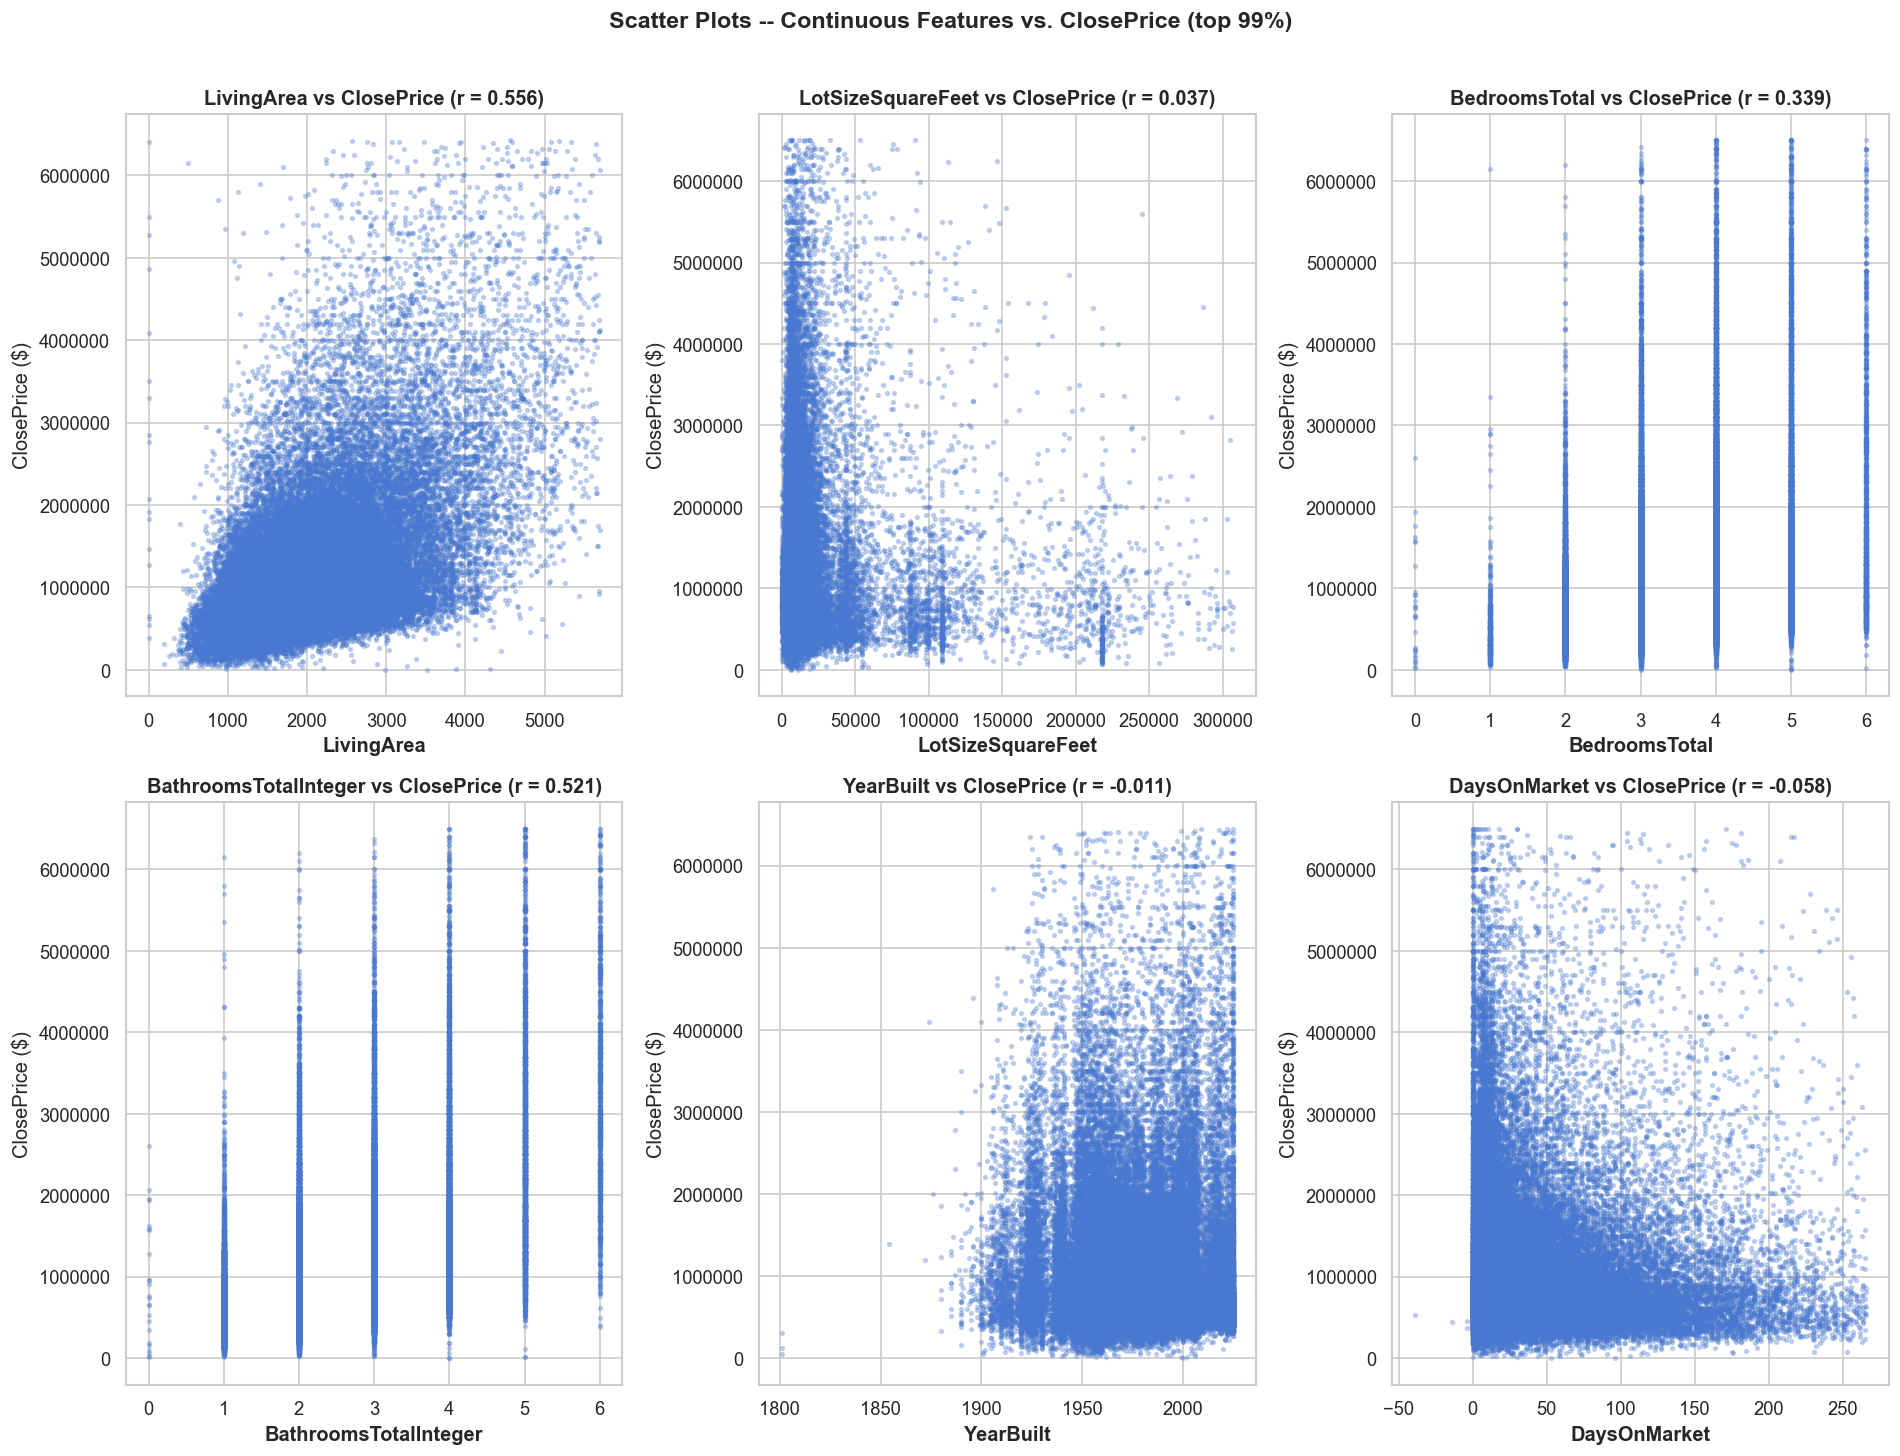

In [43]:
scatter_cols = [col for col in key_cols if col != 'ClosePrice']

fig, axes = plt.subplots(2,3, figsize = (16,12))
axes = axes.flatten()

for i, col in enumerate(scatter_cols):
    specific_data = data[[col, 'ClosePrice']].dropna()

    # Remove extreme outliers for cleaner visualization
    upper_price = specific_data['ClosePrice'].quantile(0.99)
    upper_feat = specific_data[col].quantile(0.99)
    specific_data = specific_data[(specific_data['ClosePrice'] <= upper_price) & (specific_data[col] <= upper_feat)]

    axes[i].scatter(specific_data[col], specific_data['ClosePrice'], alpha=0.15, s=5)
    axes[i].set_xlabel(col, fontweight='bold')
    axes[i].set_ylabel('ClosePrice ($)')
    axes[i].set_title(f'{col} vs ClosePrice (r = {specific_data[col].corr(specific_data["ClosePrice"]):.3f})',
                      fontweight='bold')
    axes[i].ticklabel_format(style='plain', axis='both')

fig.suptitle('Scatter Plots -- Continuous Features vs. ClosePrice (top 99%)', fontweight='bold', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()

### Correlation Heatmap

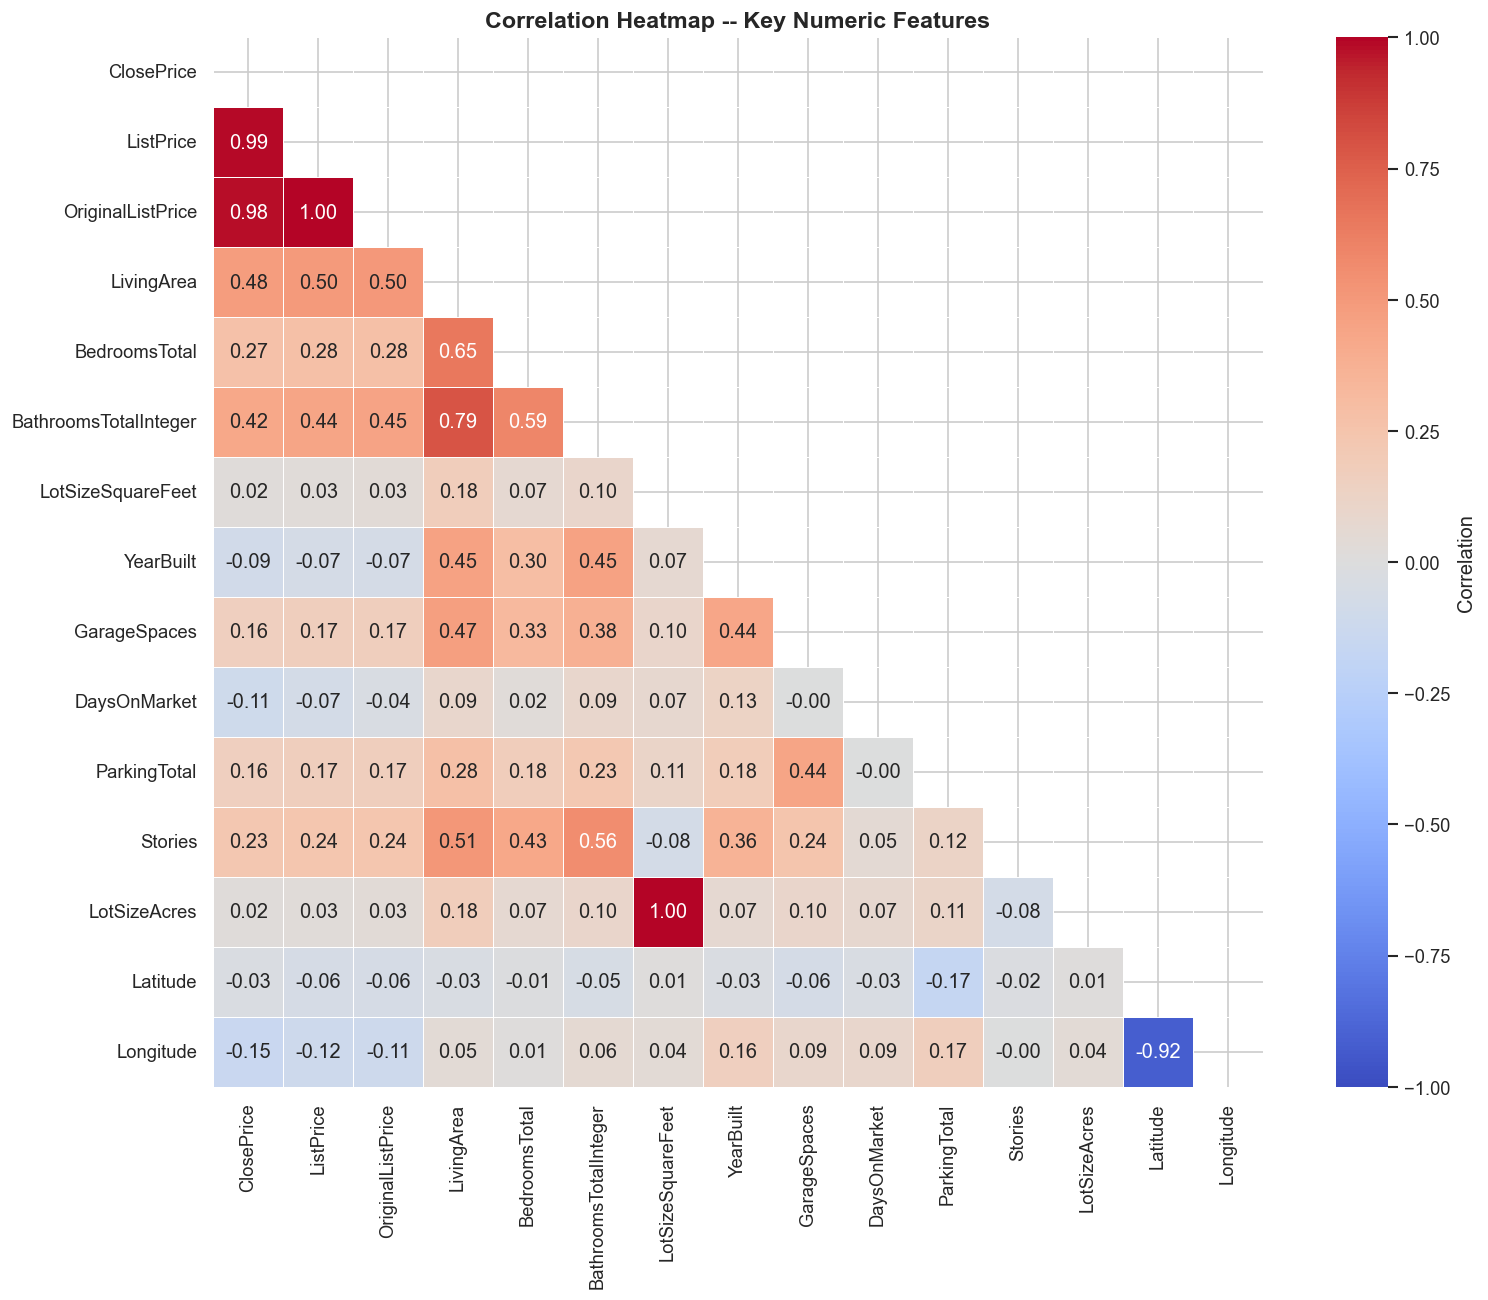

In [50]:
corr_features = ['ClosePrice', 'ListPrice', 'OriginalListPrice', 'LivingArea',
                 'BedroomsTotal', 'BathroomsTotalInteger', 'LotSizeSquareFeet',
                 'YearBuilt', 'GarageSpaces', 'DaysOnMarket', 'ParkingTotal',
                 'Stories', 'LotSizeAcres', 'Latitude', 'Longitude']

corr_data = data[corr_features].dropna()

# Cap each column at its 1st/99th percentile (drop rows outside these bounds)
for col in corr_features:
    lower = corr_data[col].quantile(0.01)
    upper = corr_data[col].quantile(0.99)
    corr_data = corr_data[(corr_data[col] >= lower) & (corr_data[col] <= upper)]

corr_matrix = corr_data.corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, ax=ax,
            vmin=-1, vmax=1, cbar_kws={'label': 'Correlation'})
ax.set_title('Correlation Heatmap -- Key Numeric Features', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

In [51]:
# top correlations with ClosePrice
print("=== Correlation with ClosePrice (Outliers Removed) ===\n")
corr_with_target = corr_matrix['ClosePrice'].drop('ClosePrice').sort_values(ascending=False)
for feat, val in corr_with_target.items():
    bar = '█' * int(abs(val) * 30)
    sign = '+' if val > 0 else '-'
    print(f"  {feat:<25s}  {sign}{abs(val):.3f}  {bar}")

=== Correlation with ClosePrice (Outliers Removed) ===

  ListPrice                  +0.989  █████████████████████████████
  OriginalListPrice          +0.983  █████████████████████████████
  LivingArea                 +0.477  ██████████████
  BathroomsTotalInteger      +0.424  ████████████
  BedroomsTotal              +0.269  ████████
  Stories                    +0.231  ██████
  ParkingTotal               +0.162  ████
  GarageSpaces               +0.157  ████
  LotSizeSquareFeet          +0.023  
  LotSizeAcres               +0.023  
  Latitude                   -0.028  
  YearBuilt                  -0.093  ██
  DaysOnMarket               -0.105  ███
  Longitude                  -0.146  ████


**Correlation Summary:** 
* `ListPrice` and `OriginalListPrice` are both nearly perfectly correlated with `ClosePrice` (r = 0.989 and r = 0.983, respectively)—consider excluding them from the model as they are basically the answer.  
* `LivingArea` (r = 0.477) and `BathroomsTotalInteger` (r = 0.424) are the strongest "real" predictors; they, along with `BedroomsTotal`, are also significantly correlated with each other, which needs to be accounted for in the modeling phase

### Data Volume and Representation
By visualizing the data's distribution across time and geography, we can identify potential bias

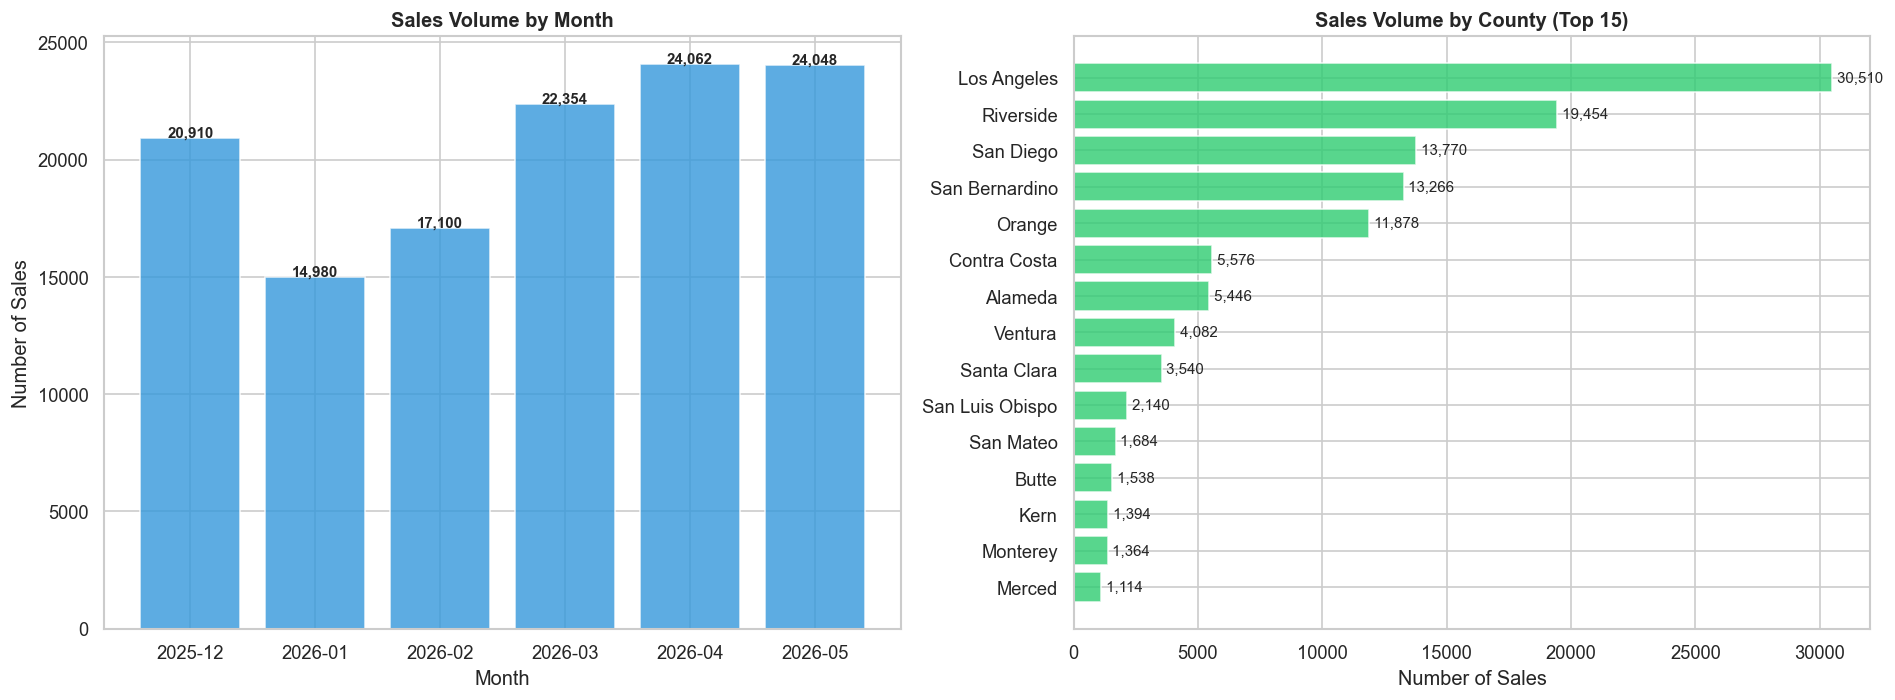

In [54]:
# create a CloseMonth column from CloseDate
data['CloseDate'] = pd.to_datetime(data['CloseDate'])
data['CloseMonth'] = data['CloseDate'].dt.to_period('M')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Records per month
monthly_counts = data.groupby('CloseMonth').size()
axes[0].bar(monthly_counts.index.astype(str), monthly_counts.values, color='#3498db', alpha=0.8)
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Number of Sales')
axes[0].set_title('Sales Volume by Month', fontweight='bold')
for i, v in enumerate(monthly_counts.values):
    axes[0].text(i, v + 50, f"{v:,}", ha='center', fontweight='bold', fontsize=9)

# Records per county (top 15)
county_counts = data['CountyOrParish'].value_counts().head(15)
axes[1].barh(county_counts.index[::-1], county_counts.values[::-1], color='#2ecc71', alpha=0.8)
axes[1].set_xlabel('Number of Sales')
axes[1].set_title('Sales Volume by County (Top 15)', fontweight='bold')
for i, v in enumerate(county_counts.values[::-1]):
    axes[1].text(v + 30, i, f" {v:,}", va='center', fontsize=9)

plt.tight_layout()
plt.show()

**Data Representation Summary:** Listings in SoCal make up a vast majority of the records. Models may predict best for listings in these regions, but may struggle for listings in underrepresented areas, such as rural NorCal.

### Overall Summary

| Area | Key Finding | Implication |
|---|---|---|
| **Missing Data** | Multiple columns (`CoveredSpaces`, `FireplacesTotal`) are 100% missing; `MainLevelBedrooms`, `Flooring` partially missing | Drop fully-empty columns; impute or flag partially missing ones rather than dropping |
| **Outliers** | Extreme values in `ClosePrice` (max $796M), `LivingArea` (max 23,314 sq ft), `LotSizeSquareFeet` (max ~1.9B sq ft — likely a data error) | Cap/filter before modeling, or they'll distort correlations and model fit |
| **Target Distribution** | `ClosePrice` is heavily right-skewed; `log1p(ClosePrice)` normalizes it | Use log-transformed target for linear models instead of raw price |
| **Correlation — Leakage Risk** | `ListPrice` (r = 0.989) and `OriginalListPrice` (r = 0.983) are nearly perfectly correlated with `ClosePrice` | Likely leak the answer; consider excluding from predictive modeling |
| **Correlation — Real Predictors** | `LivingArea` (r = 0.477) and `BathroomsTotalInteger` (r = 0.424) are the strongest genuine predictors; `BedroomsTotal` also correlated | Strong candidates for modeling, but multicollinearity between them needs to be addressed |
| **Time Representation** | Sales volume fairly stable month-to-month (~15K–24K), with a January dip | Check whether this is seasonal or an artifact of a short data window |
| **Geographic Representation** | SoCal counties (LA, Riverside, San Diego, San Bernardino, Orange) dominate the dataset | Model likely to perform best in SoCal and worse in underrepresented regions (e.g., rural NorCal); consider stratified evaluation |